<a href="https://colab.research.google.com/github/halimAhtasham/Network-_Intrusion_Detection---All_In_One/blob/main/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Common Models:
['Random Forest', 'Logistic Regression', 'KNN', 'Decision Tree', 'XGBoost']


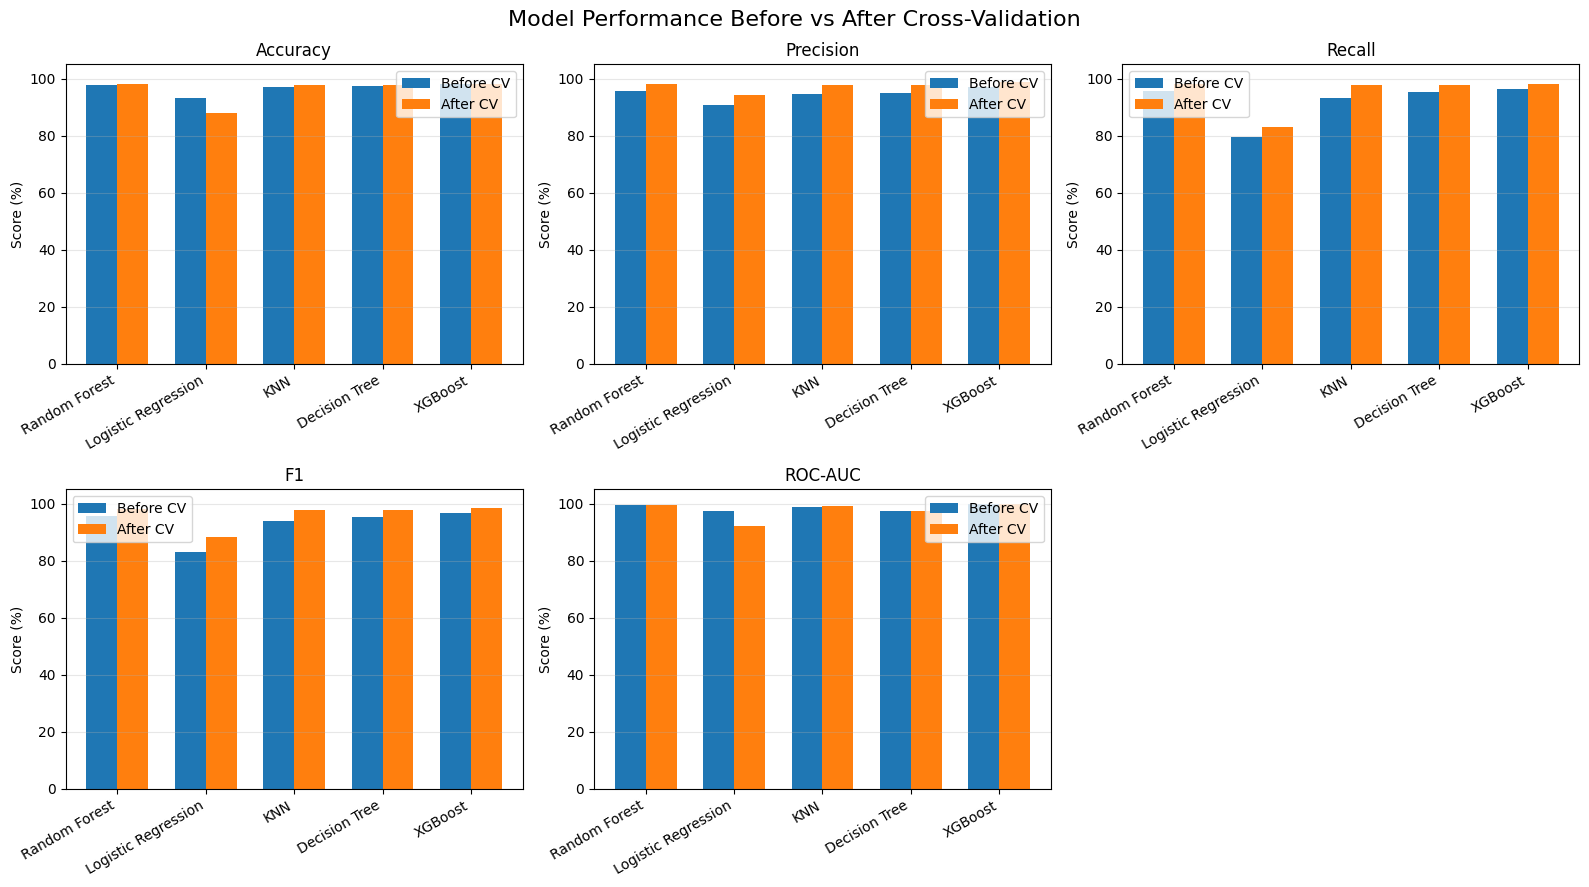

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


before = pd.read_csv("comparison_before_crossValidation.csv")
after = pd.read_csv("comparison_after_crossValidation.csv")


before["Model"] = before["Model"].replace({
    "K-Nearest Neighbors": "KNN"
})


before = before.rename(columns={
    "F1 Score": "F1",
    "ROC AUC Score": "ROC-AUC"
})

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

before[metrics] = before[metrics] * 100


common_models = [
    model for model in before["Model"]
    if model in after["Model"].values
]

print("Common Models:")
print(common_models)


before = before.set_index("Model")
after = after.set_index("Model")


fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9)
)

axes = axes.flatten()


for i, metric in enumerate(metrics):

    x = np.arange(len(common_models))

    width = 0.35

    # Before CV
    axes[i].bar(
        x - width/2,
        before.loc[common_models, metric],
        width,
        label="Before CV"
    )

    # After CV
    axes[i].bar(
        x + width/2,
        after.loc[common_models, metric],
        width,
        label="After CV"
    )

    # Labels
    axes[i].set_title(metric)

    axes[i].set_xticks(x)

    axes[i].set_xticklabels(
        common_models,
        rotation=30,
        ha="right"
    )

    axes[i].set_ylabel("Score (%)")

    axes[i].set_ylim(0, 105)

    axes[i].legend()

    axes[i].grid(
        axis="y",
        alpha=0.3
    )



fig.delaxes(axes[5])

# =========================

plt.suptitle(
    "Model Performance Before vs After Cross-Validation",
    fontsize=16
)

plt.tight_layout()

plt.show()